In [247]:
import pandas as pd
import numpy as np
import random
import os

from tqdm import tqdm
import warnings

import pandas_ta as ta
from xgboost import XGBRegressor
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [248]:
train = pd.read_pickle("./data/train_완료.pkl")
test = pd.read_pickle("./data/prediction_완료.pkl")

In [253]:
# XGBoost 하이퍼파라미터의 탐색 공간 정의
# param_grid = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.05, 0.1, 0.2],
#     'min_child_weight': [1, 3],
#     'subsample': [0.7, 1],
#     'colsample_bytree': [0.7, 1]
# }

param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'min_child_weight': [1, 3],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}


X = train.drop(['date', 'ticker', 'target', 'pct_change', 'class_target'], axis=1) 
y = train['class_target'] # class_target이 종속 변수 Y (분류 모델)

test_final_day = test[test['date'] == "2023-07-28"] # 상승/보합/하락 분류 모델이므로 마지막 날만 사용하면 됨. # 5월 30일
X_pred = test_final_day.drop(['date', 'ticker', 'target'], axis=1)

model = XGBClassifier(tree_method='gpu_hist', n_jobs=-1)

# GridSearchCV를 사용하여 최적의 하이퍼파라미터 탐색
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=2, n_jobs=-1)
grid_search.fit(X, y)

# 최적의 파라미터와 최고 정확도 출력
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# 최적의 파라미터로 모델을 다시 학습
best_model = grid_search.best_estimator_
best_model.fit(X, y)

predictions = best_model.predict(X_pred)

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.7}
Best Accuracy: 0.6300732678685435


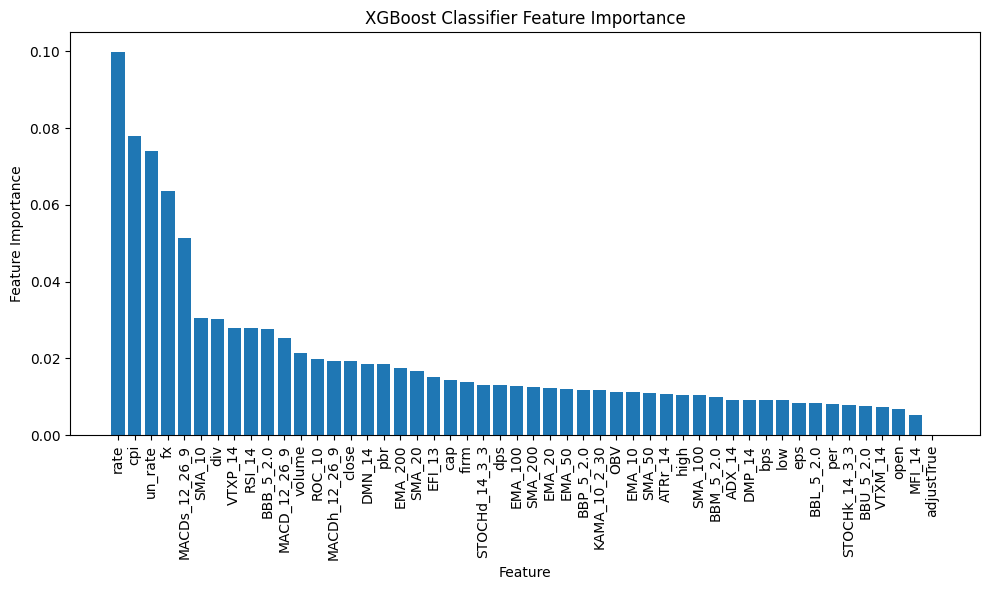

In [254]:
feature_importance = best_model.feature_importances_

# feature importance를 내림차순으로 정렬하여 시각화
sorted_idx = feature_importance.argsort()[::-1]
sorted_feature_importance = feature_importance[sorted_idx]
sorted_feature_names = X.columns[sorted_idx]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_feature_importance)), sorted_feature_importance, tick_label=sorted_feature_names)
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Feature Importance')
plt.title('XGBoost Classifier Feature Importance')
plt.tight_layout()
plt.show()

In [255]:
result = pd.DataFrame(test_final_day['ticker'].unique(), predictions, columns=["종목코드"])
result = result.reset_index()
result["예상"] = result['index']
result = result.drop("index", axis=1)

result_class_df = result

In [256]:
result_class_df

,종목코드,예상
0,A000020,0
1,A000040,0
2,A000050,0
3,A000070,0
4,A000080,0
...,...,...
1837,A375500,0
1838,A378850,0
1839,A383220,0
1840,A383310,2


---

# 리그레션

In [258]:
# XGBoost 하이퍼파라미터의 탐색 공간 정의
# param_grid = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.05, 0.1, 0.2],
#     'min_child_weight': [1, 3],
#     'subsample': [0.7, 1],
#     'colsample_bytree': [0.7, 1]
# }

param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'min_child_weight': [1, 3],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}


X = train.drop(['date', 'ticker', 'target', 'pct_change', 'class_target'], axis=1) 
y = train['target'] # class_target이 종속 변수 Y (분류 모델)

model = XGBRegressor(tree_method='gpu_hist', n_jobs=-1)

# GridSearchCV를 사용하여 최적의 하이퍼파라미터 탐색
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=2, n_jobs=-1)
grid_search.fit(X, y)

# 최적의 파라미터와 최고 정확도 출력
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# 최적의 파라미터로 모델을 다시 학습
best_model = grid_search.best_estimator_

best_model.fit(X, y)
X_pred = test.drop(['date', 'ticker', 'target'], axis=1)
predictions = best_model.predict(X_pred)

Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1}
Best Accuracy: 0.9387111893415255


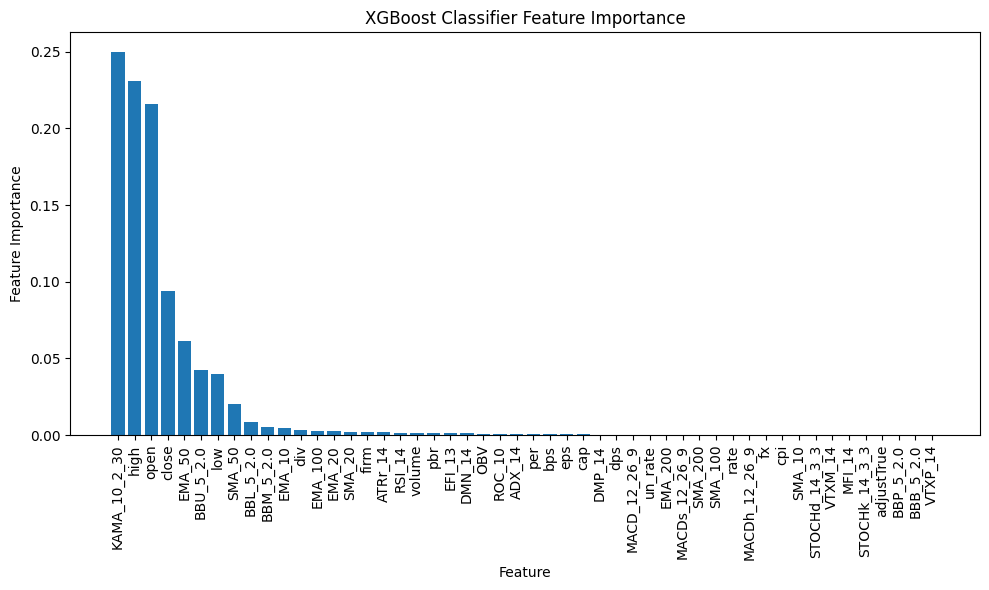

In [259]:
feature_importance = best_model.feature_importances_

# feature importance를 내림차순으로 정렬하여 시각화
sorted_idx = feature_importance.argsort()[::-1]
sorted_feature_importance = feature_importance[sorted_idx]
sorted_feature_names = X.columns[sorted_idx]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_feature_importance)), sorted_feature_importance, tick_label=sorted_feature_names)
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Feature Importance')
plt.title('XGBoost Classifier Feature Importance')
plt.tight_layout()
plt.show()

In [260]:
reg = pd.DataFrame(predictions, test['ticker'])

# 수익률 계산 함수
def calculate_return(group):
    first_value = group[0].iloc[0]
    last_value = group[0].iloc[-1]
    rate_of_change = (last_value - first_value) / first_value * 100
    return rate_of_change

# ticker 별로 수익률 계산
result_reg_df = reg.groupby('ticker').apply(calculate_return).reset_index()
result_reg_df.columns = ['ticker', 'return']

def up_or_down(df):
    conditions = [
        (df['return'] > 4), 
        (df['return'] > 0),
        (df['return'] < 0)
    ]
    choices = [2, 1, 0]
    df['class_target'] = np.select(conditions, choices, default=0)

    return df

result_reg_df = up_or_down(result_reg_df)
result_reg_df

,ticker,return,class_target
0,A000020,0.000000,0
1,A000040,0.000000,0
2,A000050,0.000000,0
3,A000070,-4.423586,0
4,A000080,0.000000,0
...,...,...,...
1839,A375500,-1.687560,0
1840,A378850,-8.072285,0
1841,A383220,-7.927198,0
1842,A383310,41.176420,2


In [271]:
# 두 데이터프레임을 종목코드를 기준으로 inner 조인
merged_df = pd.merge(result_reg_df, result_class_df, left_on='ticker', right_on='종목코드', how='inner')
merged_df = merged_df.sort_values('return')

# When 'class_target' is equal to '예상' and the value is 0, set 'return' to -999
#merged_df.loc[(merged_df['class_target'] == merged_df['예상']) & (merged_df['class_target'] == 0), 'return'] = -999

# When 'class_target' is equal to '예상' and the value is 1 or 2, set 'return' to 999
merged_df.loc[(merged_df['class_target'] == merged_df['예상']) & (merged_df['class_target'].isin([1, 2])), 'return'] = 999
merged_df = merged_df.sort_values('return')

#short_count = merged_df[merged_df['return'] == -999].count()[0]
long_count = merged_df[merged_df['return'] == 999].count()[0]

In [285]:
merged_df

,ticker,return,class_target,종목코드,예상
452,A016790,-72.657353,0,A016790,0
1723,A297890,-66.397756,0,A297890,0
1415,A171120,-59.332913,0,A171120,0
1061,A080580,-48.572031,0,A080580,0
1580,A237820,-35.492766,0,A237820,0
...,...,...,...,...,...
986,A068760,999.000000,2,A068760,2
1840,A383310,999.000000,2,A383310,2
1608,A247540,999.000000,2,A247540,2
797,A048260,999.000000,2,A048260,2


In [315]:
# Loading the sample
sample = pd.read_csv("./sub/sample_submission.csv")
sample = sample.rename(columns={'종목코드': 'ticker', '순위': 'rating'})

# Selecting rows with missing tickers from the sample
missing_tickers = sample[~sample['ticker'].isin(merged_df['ticker'])].copy()
missing_tickers['return'] = 0

# Combining missing_tickers with merged_df and assigning rank based on 'return'
submission = pd.concat([merged_df, missing_tickers], ignore_index=True)
submission = submission.sort_values('return', ascending=False)
submission['순위'] = submission['return'].rank(method='first').astype(int)

# Renaming 'ticker' column to '종목코드'
submission = submission.rename(columns={'ticker': '종목코드1'})

# Resetting index before setting it to '종목코드' to avoid duplication
submission.reset_index(drop=True, inplace=True)

# Setting index to '종목코드'
submission = submission.set_index("종목코드1")
submission = submission.drop(['종목코드'], axis=1)

# Dropping unnecessary columns
submission = submission.drop(['return', 'rating', 'class_target', '예상'], axis=1)

# Sorting by '종목코드'
submission = submission.sort_index()

# Your submission DataFrame should now have unique ranks from 1 to 2000, sorted by '종목코드'
submission

,순위
종목코드1,
A000020,1550
A000040,1276
A000050,1274
A000070,793
A000080,1275
...,...
A375500,944
A378850,481
A383220,507


In [316]:
submission.to_csv("./sub/앙상블_최종.csv")

In [ ]:
submission = submission.reset_index()